<a href="https://colab.research.google.com/github/subashini123-ctrl/Deep-Learning-for-Vision/blob/main/EX1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original:


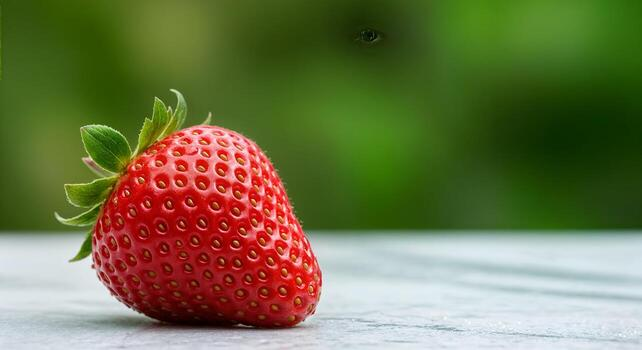

Grayscale:


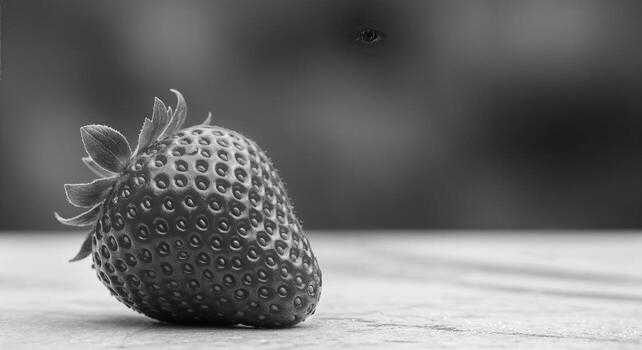

Blurred:


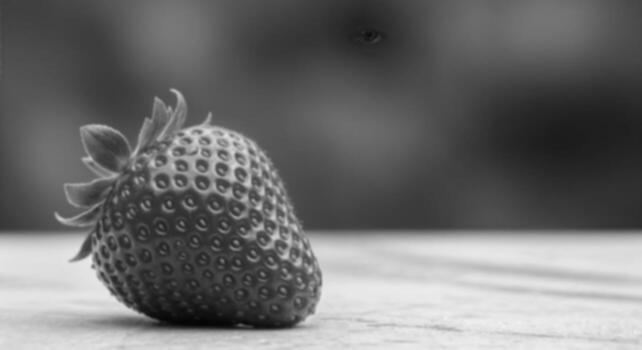

Canny Edges:


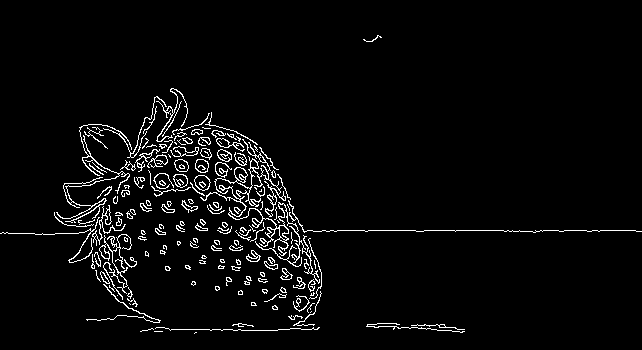

Corners:


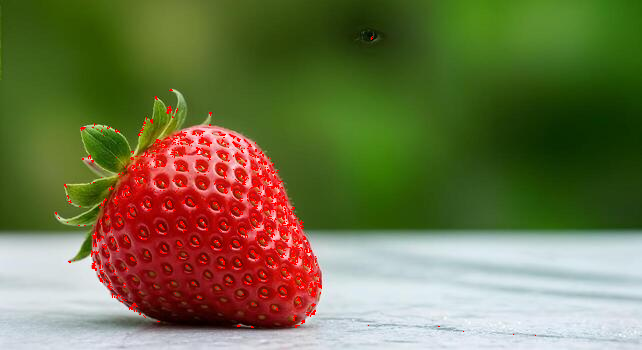

Blob:


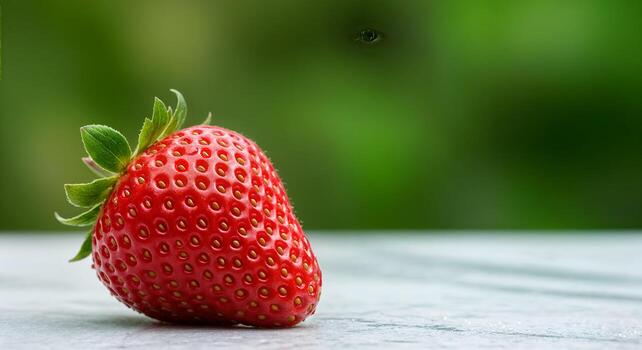

In [17]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the image
img = cv2.imread("sample.jpg")

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image 'sample.jpg'. Please ensure the file exists in the /content/ folder.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    img_corner = img.copy()
    img_corner[corners > 0.01 * corners.max()] = [0, 0, 255]

    detector = cv2.SimpleBlobDetector_create()
    keypoints = detector.detect(edges)
    img_blob = cv2.drawKeypoints(img, keypoints, None, (0, 0, 255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Display images using Colab's patch
    print("Original:")
    cv2_imshow(img)
    print("Grayscale:")
    cv2_imshow(gray)
    print("Blurred:")
    cv2_imshow(blur)
    print("Canny Edges:")
    cv2_imshow(edges)
    print("Corners:")
    cv2_imshow(img_corner)
    print("Blob:")
    cv2_imshow(img_blob)